<a href="https://colab.research.google.com/github/Mhamuda/CSEM2151-Computer_Vision/blob/main/4_ImageGeneration_VAE_DDPM_LDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Connect to google drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


#Import libraries

In [ ]:
import os
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import transforms
from torchvision.utils import save_image, make_grid

from tqdm.auto import tqdm

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


#Create project folders

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Computer_Vision_Assignments/Assignment4"

DATASET_DIR = "/content/drive/MyDrive/Computer_Vision_Assignments/FlowerDataset"

SAVED_MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "Saved_Models"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "Results"
)

VAE_DIR = os.path.join(
    RESULTS_DIR,
    "VAE"
)

DDPM_DIR = os.path.join(
    RESULTS_DIR,
    "DDPM"
)

LDM_DIR = os.path.join(
    RESULTS_DIR,
    "LDM"
)

COMPARISON_DIR = os.path.join(
    RESULTS_DIR,
    "Comparisons"
)

GENERATED_DIR = os.path.join(
    RESULTS_DIR,
    "Generated_Images"
)

for folder in [
    PROJECT_DIR,
    SAVED_MODEL_DIR,
    RESULTS_DIR,
    VAE_DIR,
    DDPM_DIR,
    LDM_DIR,
    COMPARISON_DIR,
    GENERATED_DIR
]:
    os.makedirs(
        folder,
        exist_ok=True
    )

print("Project folders created.")

Project folders created.


In [ ]:
IMAGE_SIZE = 64

BATCH_SIZE = 16

EPOCHS = 20

PATIENCE = 5

LEARNING_RATE = 1e-3

LATENT_DIM = 128

NUM_WORKERS = 2

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Early stopping patience:", PATIENCE)
print("Latent dimension:", LATENT_DIM)

Image size: 64
Batch size: 16
Epochs: 20
Early stopping patience: 5
Latent dimension: 128


#Check dataset

In [ ]:
valid_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

image_files = [
    file
    for file in os.listdir(DATASET_DIR)
    if file.lower().endswith(valid_extensions)
]

print("Total images:", len(image_files))

print("\nFirst 10 files:")
for file in image_files[:10]:
    print(file)

Total images: 105

First 10 files:
IMG_20241228_104154.jpg
IMG_20251027_232849.jpg
IMG_20251027_232914.jpg
IMG_20251027_233006.jpg
IMG_20251027_233136.jpg
IMAG8087.jpg
IMAG8137.jpg
IMAG8138.jpg
Mixed Roses in Garden (1).jpg
Mixed Roses in Garden (2).jpg


#Dataset preparation

In [ ]:
all_paths = [
    os.path.join(
        DATASET_DIR,
        file
    )
    for file in image_files
]

random.Random(SEED).shuffle(
    all_paths
)

train_count = int(
    0.8 * len(all_paths)
)

train_paths = all_paths[
    :train_count
]

val_paths = all_paths[
    train_count:
]

print(
    "Training images:",
    len(train_paths)
)

print(
    "Validation images:",
    len(val_paths)
)

Training images: 84
Validation images: 21


#Image transformation

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        10
    ),

    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),

    transforms.ToTensor()
])


val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor()
])

#Dataset class

In [ ]:
class RosePathDataset(Dataset):

    def __init__(
        self,
        image_paths,
        transform
    ):

        self.image_paths = image_paths

        self.transform = transform

    def __len__(self):

        return len(
            self.image_paths
        )

    def __getitem__(self, index):

        image = Image.open(
            self.image_paths[index]
        ).convert("RGB")

        image = self.transform(
            image
        )

        return image

#DataLoaders

In [ ]:
train_dataset = RosePathDataset(
    train_paths,
    train_transform
)

val_dataset = RosePathDataset(
    val_paths,
    val_transform
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

Train batches: 6
Validation batches: 2


#Visualize sample images

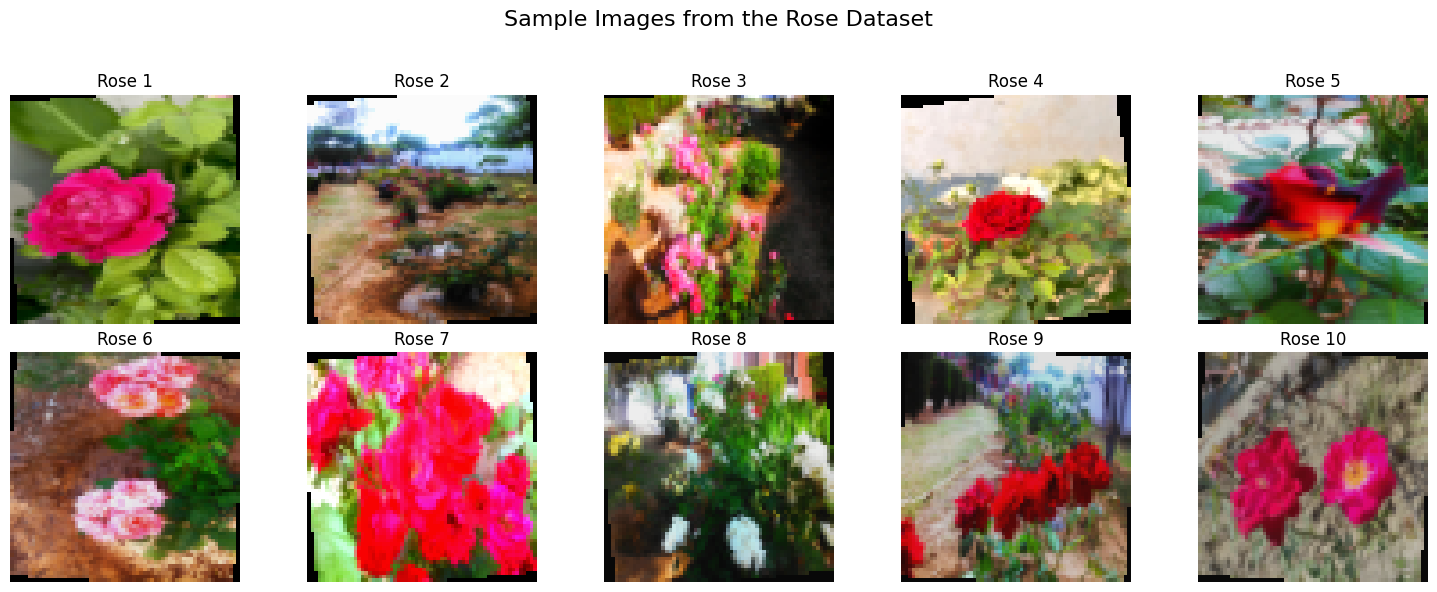

In [ ]:
images = next(
    iter(train_loader)
)

images = images[:10]

fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 6)
)

for i in range(10):

    image = images[i].permute(
        1,
        2,
        0
    ).numpy()

    axes[
        i // 5,
        i % 5
    ].imshow(image)

    axes[
        i // 5,
        i % 5
    ].set_title(
        f"Rose {i + 1}"
    )

    axes[
        i // 5,
        i % 5
    ].axis("off")


plt.suptitle(
    "Sample Images from the Rose Dataset",
    fontsize=16
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)


sample_path = os.path.join(
    RESULTS_DIR,
    "Rose_Dataset_Samples.png"
)

plt.savefig(
    sample_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Permanent checkpoint function

In [ ]:
def save_training_checkpoint(
    model,
    optimizer,
    epoch,
    train_losses,
    val_losses,
    best_val_loss,
    training_time,
    filename
):

    checkpoint = {

        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "train_losses":
            train_losses,

        "val_losses":
            val_losses,

        "best_val_loss":
            best_val_loss,

        "training_time_seconds":
            training_time
    }

    save_path = os.path.join(
        SAVED_MODEL_DIR,
        filename
    )

    torch.save(
        checkpoint,
        save_path
    )

    return save_path

#Check GPU memory

In [ ]:
if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU Memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2
        ),
        "GB"
    )

else:

    print(
        "GPU is not available."
    )

GPU: Tesla T4
GPU Memory: 14.56 GB


#VAE Architecture

In [ ]:
class VAE(nn.Module):

    def __init__(
        self,
        latent_dim=128
    ):

        super().__init__()

        self.latent_dim = latent_dim

        # -------------------------
        # Encoder
        # -------------------------

        self.encoder = nn.Sequential(

            nn.Conv2d(
                3, 32,
                4, 2, 1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(
                32, 64,
                4, 2, 1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(
                64, 128,
                4, 2, 1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Conv2d(
                128, 256,
                4, 2, 1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True)
        )

        self.fc_mu = nn.Linear(
            256 * 4 * 4,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            256 * 4 * 4,
            latent_dim
        )

        # -------------------------
        # Decoder
        # -------------------------

        self.fc_decode = nn.Linear(
            latent_dim,
            256 * 4 * 4
        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(
                256, 128,
                4, 2, 1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                128, 64,
                4, 2, 1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                64, 32,
                4, 2, 1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                32, 3,
                4, 2, 1
            ),

            nn.Sigmoid()
        )


    def encode(self, x):

        x = self.encoder(x)

        x = x.view(
            x.size(0),
            -1
        )

        mu = self.fc_mu(x)

        logvar = self.fc_logvar(x)

        return mu, logvar


    def reparameterize(
        self,
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )

        epsilon = torch.randn_like(
            std
        )

        return (
            mu
            + epsilon * std
        )


    def decode(self, z):

        x = self.fc_decode(z)

        x = x.view(
            x.size(0),
            256,
            4,
            4
        )

        return self.decoder(x)


    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstruction = self.decode(z)

        return (
            reconstruction,
            mu,
            logvar
        )

#KL-Divergence Loss

In [ ]:
def kl_divergence(
    mu,
    logvar
):

    kl = -0.5 * torch.sum(
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    return (
        kl / mu.size(0)
    )

#VAE Loss

In [ ]:
def calculate_vae_loss(
    reconstruction,
    target,
    mu,
    logvar,
    loss_type
):

    if loss_type == "BCE":

        reconstruction_loss = F.binary_cross_entropy(
            reconstruction,
            target,
            reduction="sum"
        ) / target.size(0)

    elif loss_type == "MSE":

        reconstruction_loss = F.mse_loss(
            reconstruction,
            target,
            reduction="sum"
        ) / target.size(0)

    else:

        raise ValueError(
            "loss_type must be BCE or MSE"
        )

    kl_loss = kl_divergence(
        mu,
        logvar
    )

    total_loss = (
        reconstruction_loss
        + kl_loss
    )

    return (
        total_loss,
        reconstruction_loss,
        kl_loss
    )

#VAE training function

In [ ]:
def train_vae_model(
    model,
    optimizer,
    loss_type,
    model_name
):

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")

    patience_counter = 0

    start_time = time.time()

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        # =========================
        # Training
        # =========================

        model.train()

        running_train_loss = 0.0

        for images in train_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad()

            reconstruction, mu, logvar = model(
                images
            )

            loss, _, _ = calculate_vae_loss(
                reconstruction,
                images,
                mu,
                logvar,
                loss_type
            )

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        train_loss = (
            running_train_loss
            / len(train_loader)
        )

        # =========================
        # Validation
        # =========================

        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for images in val_loader:

                images = images.to(
                    device,
                    non_blocking=True
                )

                reconstruction, mu, logvar = model(
                    images
                )

                loss, _, _ = calculate_vae_loss(
                    reconstruction,
                    images,
                    mu,
                    logvar,
                    loss_type
                )

                running_val_loss += loss.item()

        val_loss = (
            running_val_loss
            / len(val_loader)
        )

        train_losses.append(
            train_loss
        )

        val_losses.append(
            val_loss
        )

        elapsed_time = (
            time.time()
            - start_time
        )

        print(
            f"Epoch [{epoch}/{EPOCHS}] "
            f"| Train Loss: {train_loss:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Time: {elapsed_time:.2f}s"
        )

        # =========================
        # Save every epoch
        # =========================

        save_training_checkpoint(

            model,

            optimizer,

            epoch,

            train_losses,

            val_losses,

            best_val_loss,

            elapsed_time,

            f"{model_name}_Epoch_{epoch:02d}.pth"
        )

        # =========================
        # Best model
        # =========================

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            patience_counter = 0

            save_training_checkpoint(

                model,

                optimizer,

                epoch,

                train_losses,

                val_losses,

                best_val_loss,

                elapsed_time,

                f"{model_name}_Best.pth"
            )

            print(
                "  Best model saved."
            )

        else:

            patience_counter += 1

            print(
                f"  No improvement "
                f"({patience_counter}/{PATIENCE})"
            )

        # =========================
        # Early stopping
        # =========================

        if patience_counter >= PATIENCE:

            print(
                "\nEarly stopping."
            )

            break

    total_time = (
        time.time()
        - start_time
    )

    # =========================
    # Final model
    # =========================

    save_training_checkpoint(

        model,

        optimizer,

        len(train_losses),

        train_losses,

        val_losses,

        best_val_loss,

        total_time,

        f"{model_name}_Final.pth"
    )

    print(
        "\nTraining completed."
    )

    print(
        f"Total training time: "
        f"{total_time:.2f} seconds"
    )

    return (
        train_losses,
        val_losses,
        total_time
    )

#Train VAE with BCE

In [ ]:
vae_bce = VAE(
    LATENT_DIM
).to(device)

optimizer_bce = torch.optim.Adam(
    vae_bce.parameters(),
    lr=LEARNING_RATE
)

bce_train_losses, bce_val_losses, bce_time = train_vae_model(

    vae_bce,

    optimizer_bce,

    "BCE",

    "VAE_BCE"
)

Epoch [1/20] | Train Loss: 9008.1481 | Val Loss: 8570.0889 | Time: 8.51s
  Best model saved.
Epoch [2/20] | Train Loss: 8345.5547 | Val Loss: 8332.2676 | Time: 18.54s
  Best model saved.
Epoch [3/20] | Train Loss: 7994.2097 | Val Loss: 7909.0132 | Time: 26.59s
  Best model saved.
Epoch [4/20] | Train Loss: 7733.3459 | Val Loss: 7456.2854 | Time: 38.60s
  Best model saved.
Epoch [5/20] | Train Loss: 7573.7155 | Val Loss: 7296.4697 | Time: 47.00s
  Best model saved.
Epoch [6/20] | Train Loss: 7426.0151 | Val Loss: 7409.2917 | Time: 56.55s
  No improvement (1/5)
Epoch [7/20] | Train Loss: 7384.7004 | Val Loss: 7135.3899 | Time: 65.78s
  Best model saved.
Epoch [8/20] | Train Loss: 7369.9531 | Val Loss: 7148.7532 | Time: 77.91s
  No improvement (1/5)
Epoch [9/20] | Train Loss: 7334.8484 | Val Loss: 7049.1426 | Time: 84.69s
  Best model saved.
Epoch [10/20] | Train Loss: 7353.3769 | Val Loss: 6982.4822 | Time: 96.20s
  Best model saved.
Epoch [11/20] | Train Loss: 7196.0707 | Val Loss: 7022

#Train VAE with MSE

In [ ]:
vae_mse = VAE(
    LATENT_DIM
).to(device)

optimizer_mse = torch.optim.Adam(
    vae_mse.parameters(),
    lr=LEARNING_RATE
)

mse_train_losses, mse_val_losses, mse_time = train_vae_model(

    vae_mse,

    optimizer_mse,

    "MSE",

    "VAE_MSE"
)

Epoch [1/20] | Train Loss: 1519.1528 | Val Loss: 1329.6016 | Time: 9.62s
  Best model saved.
Epoch [2/20] | Train Loss: 1140.5109 | Val Loss: 1214.4441 | Time: 21.51s
  Best model saved.
Epoch [3/20] | Train Loss: 1035.0923 | Val Loss: 1099.0179 | Time: 28.85s
  Best model saved.
Epoch [4/20] | Train Loss: 990.8946 | Val Loss: 984.3658 | Time: 39.65s
  Best model saved.
Epoch [5/20] | Train Loss: 961.2018 | Val Loss: 867.5170 | Time: 48.78s
  Best model saved.
Epoch [6/20] | Train Loss: 904.2377 | Val Loss: 819.3916 | Time: 61.15s
  Best model saved.
Epoch [7/20] | Train Loss: 885.9317 | Val Loss: 815.8200 | Time: 68.30s
  Best model saved.
Epoch [8/20] | Train Loss: 797.5774 | Val Loss: 760.6137 | Time: 79.75s
  Best model saved.
Epoch [9/20] | Train Loss: 820.7318 | Val Loss: 739.8438 | Time: 87.42s
  Best model saved.
Epoch [10/20] | Train Loss: 785.1893 | Val Loss: 695.2169 | Time: 98.63s
  Best model saved.
Epoch [11/20] | Train Loss: 746.5378 | Val Loss: 712.4444 | Time: 110.61s


#VAE loss comparison

In [ ]:
vae_results = pd.DataFrame({

    "Model": [
        "VAE + BCE",
        "VAE + MSE"
    ],

    "Best Validation Loss": [
        min(bce_val_losses),
        min(mse_val_losses)
    ],

    "Training Time (seconds)": [
        bce_time,
        mse_time
    ],

    "Epochs Completed": [
        len(bce_train_losses),
        len(mse_train_losses)
    ]
})

display(
    vae_results
)

vae_results.to_csv(
    os.path.join(
        COMPARISON_DIR,
        "VAE_BCE_MSE_Comparison.csv"
    ),
    index=False
)

,Model,Best Validation Loss,Training Time (seconds),Epochs Completed
0,VAE + BCE,6830.704834,190.858459,20
1,VAE + MSE,574.613922,197.317755,20


#Generate 5 VAE images

In [ ]:
def generate_vae_figure(
    model,
    mean,
    variance,
    model_name,
    loss_name,
    sampling_name
):

    model.eval()

    std = np.sqrt(variance)

    with torch.no_grad():

        z = (
            torch.randn(
                5,
                LATENT_DIM,
                device=device
            ) * std + mean
        )

        generated = model.decode(z)

    generated = generated.clamp(0, 1)

    # -----------------------------
    # Create figure
    # -----------------------------

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(15, 3.5)
    )

    for i in range(5):

        image = generated[i].permute(
            1, 2, 0
        ).cpu().numpy()

        axes[i].imshow(image)

        axes[i].set_title(
            f"Sample {i + 1}"
        )

        axes[i].axis("off")

    # -----------------------------
    # Academic title
    # -----------------------------

    if sampling_name == "N5":

        title = (
            f"VAE Generated Rose Images Using "
            f"{loss_name} Reconstruction Loss "
            f"(Latent Samples from N(5,1))"
        )

    else:

        title = (
            f"VAE Generated Rose Images Using "
            f"{loss_name} Reconstruction Loss"
        )

    plt.suptitle(
        title,
        fontsize=14,
        y=1.02
    )

    plt.tight_layout()

    # -----------------------------
    # Save ONLY the figure
    # -----------------------------

    figure_name = (
        f"{model_name}_{sampling_name}_Figure.png"
    )

    figure_path = os.path.join(
        VAE_DIR,
        figure_name
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return generated

#Generate BEC images

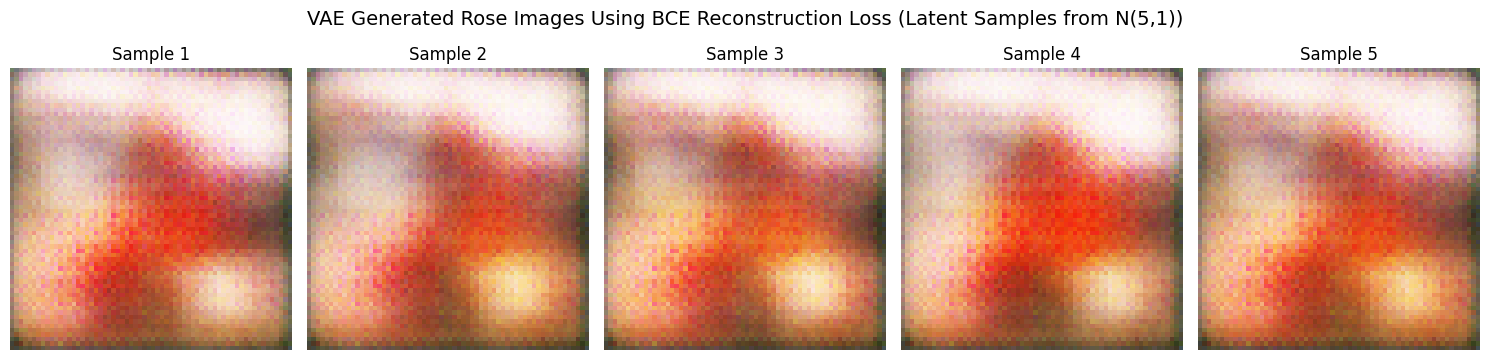

In [ ]:
vae_bce_assignment = generate_vae_figure(

    model=vae_bce,

    mean=5,

    variance=1,

    model_name="VAE_BCE",

    loss_name="BCE",

    sampling_name="N5"
)

#Generate MSE images

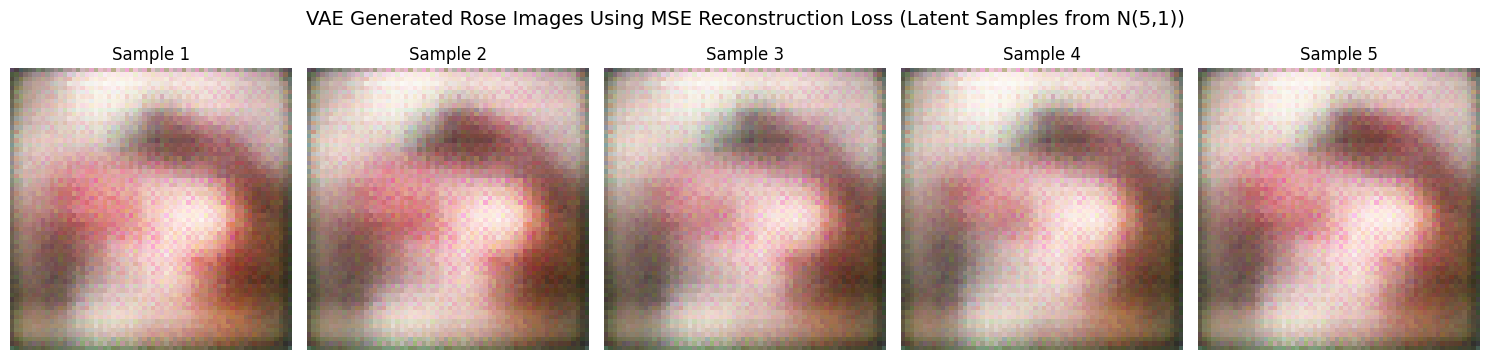

In [ ]:
vae_mse_assignment = generate_vae_figure(

    model=vae_mse,

    mean=5,

    variance=1,

    model_name="VAE_MSE",

    loss_name="MSE",

    sampling_name="N5"
)

#DDPM configuration

In [ ]:
DDPM_IMAGE_SIZE = 32

DDPM_TIMESTEPS = 100

DDPM_BASE_CHANNELS = 64

DDPM_LEARNING_RATE = 2e-4

print("DDPM image size:", DDPM_IMAGE_SIZE)
print("DDPM timesteps:", DDPM_TIMESTEPS)

DDPM image size: 32
DDPM timesteps: 100


#DDPM DataLoader

In [ ]:
ddpm_train_transform = transforms.Compose([
    transforms.Resize(
        (DDPM_IMAGE_SIZE, DDPM_IMAGE_SIZE)
    ),
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    transforms.RandomRotation(
        10
    ),
    transforms.ToTensor()
])


ddpm_val_transform = transforms.Compose([
    transforms.Resize(
        (DDPM_IMAGE_SIZE, DDPM_IMAGE_SIZE)
    ),
    transforms.ToTensor()
])


ddpm_train_dataset = RosePathDataset(
    train_paths,
    ddpm_train_transform
)

ddpm_val_dataset = RosePathDataset(
    val_paths,
    ddpm_val_transform
)


ddpm_train_loader = DataLoader(
    ddpm_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

ddpm_val_loader = DataLoader(
    ddpm_val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DDPM loaders created.")

DDPM loaders created.


#Timestep embedding

In [ ]:
class DDPMSinusoidalEmbedding(nn.Module):

    def __init__(
        self,
        embedding_dim
    ):

        super().__init__()

        self.embedding_dim = embedding_dim

    def forward(self, t):

        half_dim = self.embedding_dim // 2

        scale = np.log(10000) / (
            half_dim - 1
        )

        scale = torch.exp(
            torch.arange(
                half_dim,
                device=t.device
            ) * -scale
        )

        embedding = (
            t.float().unsqueeze(1)
            * scale.unsqueeze(0)
        )

        embedding = torch.cat(
            [
                torch.sin(embedding),
                torch.cos(embedding)
            ],
            dim=1
        )

        return embedding

#Residual block

In [ ]:
class DDPMResidualBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(
            8,
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.time_projection = nn.Linear(
            time_dim,
            out_channels
        )

        if in_channels != out_channels:

            self.shortcut = nn.Conv2d(
                in_channels,
                out_channels,
                1
            )

        else:

            self.shortcut = nn.Identity()


    def forward(
        self,
        x,
        time_embedding
    ):

        residual = self.shortcut(x)

        x = self.conv1(x)

        x = self.norm1(x)

        x = F.silu(x)

        time = self.time_projection(
            time_embedding
        )

        time = time.unsqueeze(
            -1
        ).unsqueeze(
            -1
        )

        x = x + time

        x = self.conv2(x)

        x = self.norm2(x)

        x = F.silu(x)

        return x + residual

#Simple DDPM U-Net

In [ ]:
class ImprovedDDPMUNet(nn.Module):

    def __init__(
        self,
        base_channels=64
    ):

        super().__init__()

        time_dim = base_channels * 4

        self.time_embedding = nn.Sequential(

            DDPMSinusoidalEmbedding(
                time_dim
            ),

            nn.Linear(
                time_dim,
                time_dim
            ),

            nn.SiLU(),

            nn.Linear(
                time_dim,
                time_dim
            )
        )

        # -------------------------
        # Input
        # -------------------------

        self.input_conv = nn.Conv2d(
            3,
            base_channels,
            3,
            padding=1
        )

        # -------------------------
        # Encoder
        # -------------------------

        self.down1 = DDPMResidualBlock(
            base_channels,
            base_channels,
            time_dim
        )

        self.down2 = DDPMResidualBlock(
            base_channels,
            base_channels * 2,
            time_dim
        )

        self.downsample1 = nn.Conv2d(
            base_channels * 2,
            base_channels * 2,
            4,
            2,
            1
        )

        self.down3 = DDPMResidualBlock(
            base_channels * 2,
            base_channels * 4,
            time_dim
        )

        self.downsample2 = nn.Conv2d(
            base_channels * 4,
            base_channels * 4,
            4,
            2,
            1
        )

        # -------------------------
        # Middle
        # -------------------------

        self.mid1 = DDPMResidualBlock(
            base_channels * 4,
            base_channels * 4,
            time_dim
        )

        self.mid2 = DDPMResidualBlock(
            base_channels * 4,
            base_channels * 4,
            time_dim
        )

        # -------------------------
        # Decoder
        # -------------------------

        self.up1 = nn.ConvTranspose2d(
            base_channels * 4,
            base_channels * 4,
            4,
            2,
            1
        )

        self.up_block1 = DDPMResidualBlock(
            base_channels * 8,
            base_channels * 2,
            time_dim
        )

        self.up2 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels * 2,
            4,
            2,
            1
        )

        self.up_block2 = DDPMResidualBlock(
            base_channels * 4,
            base_channels,
            time_dim
        )

        self.output = nn.Sequential(

            nn.GroupNorm(
                8,
                base_channels
            ),

            nn.SiLU(),

            nn.Conv2d(
                base_channels,
                3,
                3,
                padding=1
            )
        )


    def forward(
        self,
        x,
        t
    ):

        time_embedding = self.time_embedding(t)

        x = self.input_conv(x)

        # Encoder
        e1 = self.down1(
            x,
            time_embedding
        )

        e2 = self.down2(
            e1,
            time_embedding
        )

        d1 = self.downsample1(e2)

        e3 = self.down3(
            d1,
            time_embedding
        )

        d2 = self.downsample2(e3)

        # Middle
        x = self.mid1(
            d2,
            time_embedding
        )

        x = self.mid2(
            x,
            time_embedding
        )

        # Decoder
        x = self.up1(x)

        x = torch.cat(
            [
                x,
                e3
            ],
            dim=1
        )

        x = self.up_block1(
            x,
            time_embedding
        )

        x = self.up2(x)

        x = torch.cat(
            [
                x,
                e2
            ],
            dim=1
        )

        x = self.up_block2(
            x,
            time_embedding
        )

        return self.output(x)

#Diffusion schedule

In [ ]:
ddpm_betas = torch.linspace(
    1e-4,
    0.02,
    DDPM_TIMESTEPS,
    device=device
)

ddpm_alphas = (
    1.0 - ddpm_betas
)

ddpm_alpha_bars = torch.cumprod(
    ddpm_alphas,
    dim=0
)

ddpm_sqrt_alpha_bars = torch.sqrt(
    ddpm_alpha_bars
)

ddpm_sqrt_one_minus_alpha_bars = torch.sqrt(
    1.0 - ddpm_alpha_bars
)

print("DDPM schedule ready.")

DDPM schedule ready.


#Forward diffusion function

In [ ]:
def ddpm_forward_process(
    images,
    timesteps
):

    noise = torch.randn_like(
        images
    )

    alpha_bar = ddpm_alpha_bars[
        timesteps
    ].view(
        -1,
        1,
        1,
        1
    )

    noisy_images = (
        torch.sqrt(alpha_bar)
        * images
        +
        torch.sqrt(1 - alpha_bar)
        * noise
    )

    return (
        noisy_images,
        noise
    )

#Train DDPM

In [ ]:
def train_improved_ddpm(
    model,
    optimizer
):

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")

    patience_counter = 0

    start_time = time.time()

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        model.train()

        train_total = 0.0

        progress = tqdm(
            ddpm_train_loader,
            desc=f"Epoch [{epoch}/{EPOCHS}]"
        )

        for images in progress:

            images = images.to(
                device,
                non_blocking=True
            )

            batch_size = images.size(0)

            timesteps = torch.randint(
                0,
                DDPM_TIMESTEPS,
                (batch_size,),
                device=device
            )

            noisy_images, noise = (
                ddpm_forward_process(
                    images,
                    timesteps
                )
            )

            predicted_noise = model(
                noisy_images,
                timesteps
            )

            loss = F.mse_loss(
                predicted_noise,
                noise
            )

            optimizer.zero_grad()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            train_total += loss.item()

            progress.set_postfix(
                Loss=f"{loss.item():.4f}"
            )

        train_loss = (
            train_total
            / len(ddpm_train_loader)
        )

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        val_total = 0.0

        with torch.no_grad():

            for images in ddpm_val_loader:

                images = images.to(
                    device,
                    non_blocking=True
                )

                batch_size = images.size(0)

                timesteps = torch.randint(
                    0,
                    DDPM_TIMESTEPS,
                    (batch_size,),
                    device=device
                )

                noisy_images, noise = (
                    ddpm_forward_process(
                        images,
                        timesteps
                    )
                )

                predicted_noise = model(
                    noisy_images,
                    timesteps
                )

                loss = F.mse_loss(
                    predicted_noise,
                    noise
                )

                val_total += loss.item()

        val_loss = (
            val_total
            / len(ddpm_val_loader)
        )

        train_losses.append(
            train_loss
        )

        val_losses.append(
            val_loss
        )

        elapsed = (
            time.time()
            - start_time
        )

        print(
            f"Train Loss: {train_loss:.5f} "
            f"| Val Loss: {val_loss:.5f} "
            f"| Time: {elapsed:.2f}s"
        )

        # -------------------------
        # Save every epoch
        # -------------------------

        save_training_checkpoint(

            model,

            optimizer,

            epoch,

            train_losses,

            val_losses,

            best_val_loss,

            elapsed,

            f"DDPM_Improved_Epoch_{epoch:02d}.pth"
        )

        # -------------------------
        # Best model
        # -------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            patience_counter = 0

            save_training_checkpoint(

                model,

                optimizer,

                epoch,

                train_losses,

                val_losses,

                best_val_loss,

                elapsed,

                "DDPM_Improved_Best.pth"
            )

            print(
                "Best DDPM model saved."
            )

        else:

            patience_counter += 1

            print(
                f"No improvement "
                f"({patience_counter}/{PATIENCE})"
            )

        if patience_counter >= PATIENCE:

            print(
                "Early stopping."
            )

            break

    total_time = (
        time.time()
        - start_time
    )

    save_training_checkpoint(

        model,

        optimizer,

        len(train_losses),

        train_losses,

        val_losses,

        best_val_loss,

        total_time,

        "DDPM_Improved_Final.pth"
    )

    print(
        "\nImproved DDPM training completed."
    )

    print(
        f"Training time: "
        f"{total_time:.2f} seconds"
    )

    return (
        train_losses,
        val_losses,
        total_time
    )

#Create and train DDPM

In [ ]:
ddpm_improved = ImprovedDDPMUNet(
    DDPM_BASE_CHANNELS
).to(device)

ddpm_improved_optimizer = torch.optim.AdamW(
    ddpm_improved.parameters(),
    lr=DDPM_LEARNING_RATE,
    weight_decay=1e-4
)

print(
    "Improved DDPM parameters:",
    sum(
        p.numel()
        for p in ddpm_improved.parameters()
    )
)

Improved DDPM parameters: 7644419


#Train

In [ ]:
ddpm_train_losses_new, ddpm_val_losses_new, ddpm_time_new = train_improved_ddpm(

    ddpm_improved,

    ddpm_improved_optimizer
)

Epoch [1/20]:   0%|          | 0/6 [00:00<?, ?it/s]

Train Loss: 0.93684 | Val Loss: 0.60281 | Time: 12.60s
Best DDPM model saved.


Epoch [2/20]:   0%|          | 0/6 [00:00<?, ?it/s]

Train Loss: 0.49272 | Val Loss: 0.37548 | Time: 28.54s
Best DDPM model saved.


Epoch [3/20]:   0%|          | 0/6 [00:00<?, ?it/s]

...

Train Loss: 0.20884 | Val Loss: 0.16830 | Time: 213.98s
No improvement (3/5)


Epoch [14/20]:   0%|          | 0/6 [00:00<?, ?it/s]

Train Loss: 0.21573 | Val Loss: 0.13739 | Time: 229.67s
No improvement (4/5)


Epoch [15/20]:   0%|          | 0/6 [00:00<?, ?it/s]

Train Loss: 0.15499 | Val Loss: 0.15306 | Time: 243.25s
No improvement (5/5)
Early stopping.

Improved DDPM training completed.
Training time: 243.59 seconds


#DDPM reverse diffusion

In [ ]:
@torch.no_grad()
def ddpm_reverse_process(
    model,
    num_images=5
):

    model.eval()

    x = torch.randn(
        num_images,
        3,
        DDPM_IMAGE_SIZE,
        DDPM_IMAGE_SIZE,
        device=device
    )

    for timestep in tqdm(
        reversed(
            range(
                DDPM_TIMESTEPS
            )
        ),
        total=DDPM_TIMESTEPS,
        desc="Generating DDPM images"
    ):

        t = torch.full(
            (num_images,),
            timestep,
            device=device,
            dtype=torch.long
        )

        predicted_noise = model(
            x,
            t
        )

        beta_t = ddpm_betas[
            timestep
        ]

        alpha_t = ddpm_alphas[
            timestep
        ]

        alpha_bar_t = ddpm_alpha_bars[
            timestep
        ]

        # Mean of p(x_{t-1}|x_t)
        mean = (
            1.0
            / torch.sqrt(alpha_t)
        ) * (
            x
            -
            (
                beta_t
                /
                torch.sqrt(
                    1.0 - alpha_bar_t
                )
            )
            * predicted_noise
        )

        if timestep > 0:

            previous_alpha_bar = (
                ddpm_alpha_bars[
                    timestep - 1
                ]
            )

            posterior_variance = (
                beta_t
                *
                (
                    1.0
                    - previous_alpha_bar
                )
                /
                (
                    1.0
                    - alpha_bar_t
                )
            )

            noise = torch.randn_like(
                x
            )

            x = (
                mean
                +
                torch.sqrt(
                    posterior_variance
                )
                * noise
            )

        else:

            x = mean

    return x.clamp(
        0,
        1
    )

#Generate 5 DDPM images

Generating DDPM images:   0%|          | 0/100 [00:00<?, ?it/s]

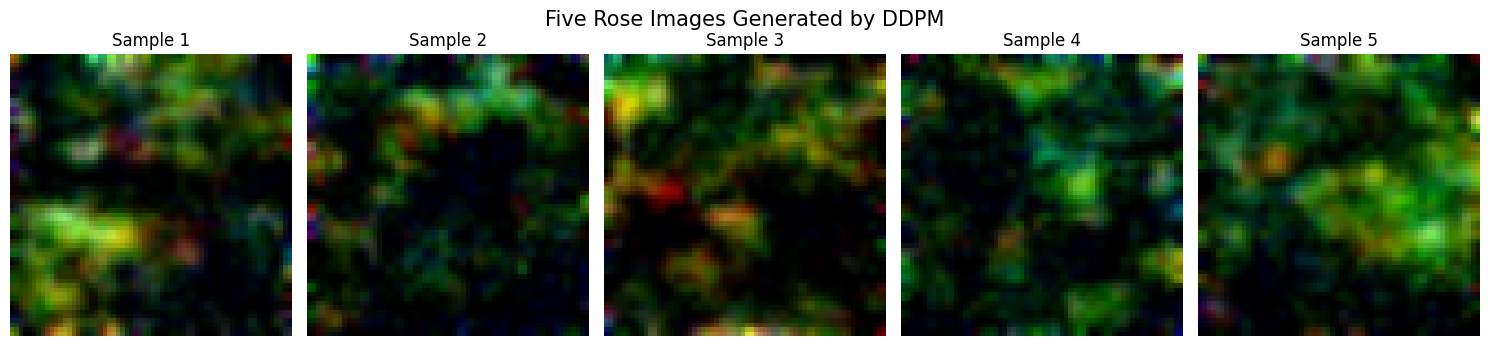

In [ ]:
ddpm_generated_new = ddpm_reverse_process(
    ddpm_improved,
    num_images=5
)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(15, 3.5)
)

for i in range(5):

    image = ddpm_generated_new[i]

    # Upscale only for visualization
    image = F.interpolate(
        image.unsqueeze(0),
        size=(64, 64),
        mode="bilinear",
        align_corners=False
    )[0]

    image = image.permute(
        1,
        2,
        0
    ).cpu().numpy()

    axes[i].imshow(
        image
    )

    axes[i].set_title(
        f"Sample {i + 1}"
    )

    axes[i].axis("off")


plt.suptitle(
    "Five Rose Images Generated by DDPM",
    fontsize=15
)

plt.tight_layout()

ddpm_figure_path = os.path.join(
    DDPM_DIR,
    "DDPM_Improved_Generated_Rose_Images.png"
)

plt.savefig(
    ddpm_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#LDM configuration

In [ ]:
LDM_IMAGE_SIZE = 64

LDM_LATENT_CHANNELS = LATENT_DIM

LDM_TIMESTEPS = 100

LDM_BASE_CHANNELS = 64

LDM_LEARNING_RATE = 2e-4

print("LDM image size:", LDM_IMAGE_SIZE)
print("LDM latent channels:", LDM_LATENT_CHANNELS)
print("LDM timesteps:", LDM_TIMESTEPS)

LDM image size: 64
LDM latent channels: 128
LDM timesteps: 100


#Load the trained BCE VAE

In [ ]:
vae_for_ldm = VAE(
    latent_dim=LATENT_DIM
).to(device)

vae_for_ldm.load_state_dict(
    vae_bce.state_dict()
)

vae_for_ldm.eval()

# Freeze VAE
for parameter in vae_for_ldm.parameters():
    parameter.requires_grad = False

print("Pretrained VAE loaded and frozen.")

Pretrained VAE loaded and frozen.


#Check the latent representation

In [ ]:
sample_images = next(
    iter(train_loader)
)

sample_images = sample_images.to(
    device
)

with torch.no_grad():

    latent_mu, latent_logvar = (
        vae_for_ldm.encode(
            sample_images
        )
    )

print(
    "Image shape:",
    sample_images.shape
)

print(
    "Latent mean shape:",
    latent_mu.shape
)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x787a78334860>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x787a78334860>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Image shape: torch.Size([16, 3, 64, 64])
Latent mean shape: torch.Size([16, 128])


# Spatial latent configuration

In [ ]:
LDM_LATENT_SIZE = 16

LDM_LATENT_CHANNELS = 4

print(
    "LDM latent representation:",
    f"{LDM_LATENT_CHANNELS} x "
    f"{LDM_LATENT_SIZE} x "
    f"{LDM_LATENT_SIZE}"
)

LDM latent representation: 4 x 16 x 16


#LDM VAE encoder

In [ ]:
class LDMEncoder(nn.Module):

    def __init__(
        self,
        latent_channels=4
    ):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                4,
                2,
                1
            ),

            nn.SiLU(),

            nn.Conv2d(
                32,
                64,
                4,
                2,
                1
            ),

            nn.GroupNorm(
                8,
                64
            ),

            nn.SiLU(),

            nn.Conv2d(
                64,
                128,
                4,
                2,
                1
            ),

            nn.GroupNorm(
                8,
                128
            ),

            nn.SiLU(),

            nn.Conv2d(
                128,
                latent_channels * 2,
                3,
                padding=1
            )
        )


    def forward(
        self,
        x
    ):

        h = self.encoder(x)

        mean, logvar = torch.chunk(
            h,
            2,
            dim=1
        )

        return mean, logvar

#LDM VAE decoder

In [ ]:
class LDMDecoder(nn.Module):

    def __init__(
        self,
        latent_channels=4
    ):

        super().__init__()

        self.decoder = nn.Sequential(

            nn.Conv2d(
                latent_channels,
                128,
                3,
                padding=1
            ),

            nn.GroupNorm(
                8,
                128
            ),

            nn.SiLU(),

            nn.ConvTranspose2d(
                128,
                64,
                4,
                2,
                1
            ),

            nn.GroupNorm(
                8,
                64
            ),

            nn.SiLU(),

            nn.ConvTranspose2d(
                64,
                32,
                4,
                2,
                1
            ),

            nn.GroupNorm(
                8,
                32
            ),

            nn.SiLU(),

            nn.ConvTranspose2d(
                32,
                16,
                4,
                2,
                1
            ),

            nn.SiLU(),

            nn.Conv2d(
                16,
                3,
                3,
                padding=1
            ),

            nn.Sigmoid()
        )


    def forward(
        self,
        z
    ):

        return self.decoder(z)

#LDM autoencoder

In [ ]:
class LDMAutoencoder(nn.Module):

    def __init__(
        self,
        latent_channels=4
    ):

        super().__init__()

        self.encoder = LDMEncoder(
            latent_channels
        )

        self.decoder = LDMDecoder(
            latent_channels
        )


    def reparameterize(
        self,
        mean,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )

        noise = torch.randn_like(
            std
        )

        return (
            mean
            +
            noise * std
        )


    def forward(
        self,
        x
    ):

        mean, logvar = self.encoder(
            x
        )

        z = self.reparameterize(
            mean,
            logvar
        )

        reconstruction = self.decoder(
            z
        )

        return (
            reconstruction,
            mean,
            logvar,
            z
        )

#Train the LDM autoencoder

In [ ]:
def train_ldm_autoencoder(
    model,
    optimizer
):

    best_loss = float("inf")

    patience_counter = 0

    start_time = time.time()

    train_losses = []

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        model.train()

        total_loss = 0.0

        for images in tqdm(
            train_loader,
            desc=f"LDM-AE Epoch [{epoch}/{EPOCHS}]"
        ):

            images = images.to(
                device
            )

            reconstruction, mean, logvar, _ = (
                model(images)
            )

            reconstruction_loss = F.mse_loss(
                reconstruction,
                images
            )

            kl_loss = -0.5 * torch.mean(
                1
                + logvar
                - mean.pow(2)
                - logvar.exp()
            )

            loss = (
                reconstruction_loss
                +
                0.0001 * kl_loss
            )

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        epoch_loss = (
            total_loss
            / len(train_loader)
        )

        train_losses.append(
            epoch_loss
        )

        elapsed = (
            time.time()
            - start_time
        )

        print(
            f"Epoch {epoch}: "
            f"Loss = {epoch_loss:.5f} "
            f"| Time = {elapsed:.2f}s"
        )

        save_training_checkpoint(
            model,
            optimizer,
            epoch,
            train_losses,
            train_losses,
            best_loss,
            elapsed,
            f"LDM_AE_Epoch_{epoch:02d}.pth"
        )

        if epoch_loss < best_loss:

            best_loss = epoch_loss

            patience_counter = 0

            save_training_checkpoint(
                model,
                optimizer,
                epoch,
                train_losses,
                train_losses,
                best_loss,
                elapsed,
                "LDM_AE_Best.pth"
            )

        else:

            patience_counter += 1

        if patience_counter >= PATIENCE:

            print(
                "LDM autoencoder early stopping."
            )

            break

    total_time = (
        time.time()
        - start_time
    )

    save_training_checkpoint(
        model,
        optimizer,
        len(train_losses),
        train_losses,
        train_losses,
        best_loss,
        total_time,
        "LDM_AE_Final.pth"
    )

    print(
        f"LDM autoencoder training time: "
        f"{total_time:.2f} seconds"
    )

    return train_losses, total_time

#Create and train LDM autoencoder

In [ ]:
ldm_autoencoder = LDMAutoencoder(
    LDM_LATENT_CHANNELS
).to(device)

ldm_ae_optimizer = torch.optim.AdamW(
    ldm_autoencoder.parameters(),
    lr=1e-3
)

ldm_ae_losses, ldm_ae_time = (
    train_ldm_autoencoder(
        ldm_autoencoder,
        ldm_ae_optimizer
    )
)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x787a78334860>
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x787a78334860>
    Traceback (most recent call last):
self._shutdown_workers()  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        self._shutdown_workers()if w.is_alive():

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
      if w.is_alive(): 
       

LDM-AE Epoch [1/20]:   0%|          | 0/6 [00:00<?, ?it/s]

  ^ ^^ ^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^
      File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
assert self._parent_pid == os.getpid(), 'can only test a child process' 
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
^
AssertionError: AssertionErrorcan only test a child process: 
can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x787a78334860>Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x787a78334860>Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del

Epoch 1: Loss = 0.09237 | Time = 12.72s


LDM-AE Epoch [2/20]:   0%|          | 0/6 [00:00<?, ?it/s]

...

Epoch 18: Loss = 0.02349 | Time = 213.80s


LDM-AE Epoch [19/20]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 19: Loss = 0.02304 | Time = 225.15s


LDM-AE Epoch [20/20]:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 20: Loss = 0.02178 | Time = 236.06s
LDM autoencoder training time: 236.17 seconds


#Test the latent space

In [ ]:
ldm_autoencoder.eval()

with torch.no_grad():

    test_batch = next(
        iter(val_loader)
    ).to(device)

    _, _, _, test_latent = (
        ldm_autoencoder(
            test_batch
        )
    )

print(
    "Input image shape:",
    test_batch.shape
)

print(
    "Latent shape:",
    test_latent.shape
)

Input image shape: torch.Size([16, 3, 64, 64])
Latent shape: torch.Size([16, 4, 8, 8])


#LDM diffusion schedule

In [ ]:
ldm_betas = torch.linspace(
    1e-4,
    0.02,
    LDM_TIMESTEPS,
    device=device
)

ldm_alphas = (
    1.0 - ldm_betas
)

ldm_alpha_bars = torch.cumprod(
    ldm_alphas,
    dim=0
)

print(
    "LDM diffusion schedule created."
)

LDM diffusion schedule created.


#LDM U-Net

In [ ]:
class LDMUNet(nn.Module):

    def __init__(
        self,
        latent_channels=4,
        base_channels=64
    ):

        super().__init__()

        time_dim = base_channels * 4

        # -------------------------
        # Timestep embedding
        # -------------------------

        self.time_embedding = nn.Sequential(

            DDPMSinusoidalEmbedding(
                time_dim
            ),

            nn.Linear(
                time_dim,
                time_dim
            ),

            nn.SiLU(),

            nn.Linear(
                time_dim,
                time_dim
            )
        )

        # -------------------------
        # Input
        # -------------------------

        self.input_conv = nn.Conv2d(
            latent_channels,
            base_channels,
            3,
            padding=1
        )

        # -------------------------
        # Encoder
        # -------------------------

        self.block1 = DDPMResidualBlock(
            base_channels,
            base_channels,
            time_dim
        )

        self.downsample = nn.Conv2d(
            base_channels,
            base_channels * 2,
            4,
            stride=2,
            padding=1
        )

        self.block2 = DDPMResidualBlock(
            base_channels * 2,
            base_channels * 2,
            time_dim
        )

        # -------------------------
        # Middle
        # -------------------------

        self.middle = DDPMResidualBlock(
            base_channels * 2,
            base_channels * 2,
            time_dim
        )

        # -------------------------
        # Decoder
        # -------------------------

        self.upsample = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            4,
            stride=2,
            padding=1
        )

        # Concatenated:
        # base_channels + base_channels
        # = base_channels * 2

        self.block3 = DDPMResidualBlock(
            base_channels * 2,
            base_channels,
            time_dim
        )

        # -------------------------
        # Output
        # -------------------------

        self.output_conv = nn.Conv2d(
            base_channels,
            latent_channels,
            3,
            padding=1
        )


    def forward(
        self,
        x,
        t
    ):

        # Timestep embedding
        time = self.time_embedding(t)

        # -------------------------
        # Encoder
        # -------------------------

        x1 = self.input_conv(x)

        x1 = self.block1(
            x1,
            time
        )

        x2 = self.downsample(
            x1
        )

        x2 = self.block2(
            x2,
            time
        )

        # -------------------------
        # Middle
        # -------------------------

        x2 = self.middle(
            x2,
            time
        )

        # -------------------------
        # Decoder
        # -------------------------

        x = self.upsample(
            x2
        )

        # Skip connection
        x = torch.cat(
            [
                x,
                x1
            ],
            dim=1
        )

        x = self.block3(
            x,
            time
        )

        return self.output_conv(x)

#Re-create the LDM model

In [ ]:
ldm = LDMUNet(
    latent_channels=LDM_LATENT_CHANNELS,
    base_channels=LDM_BASE_CHANNELS
).to(device)

ldm_optimizer = torch.optim.AdamW(
    ldm.parameters(),
    lr=LDM_LEARNING_RATE,
    weight_decay=1e-4
)

print(
    "LDM parameters:",
    sum(
        p.numel()
        for p in ldm.parameters()
    )
)

LDM parameters: 1281988


#Check the latent shape before training

In [ ]:
ldm_autoencoder.eval()

sample_batch = next(
    iter(train_loader)
)

# Handle loaders returning either:
# images
# or
# (images, labels)

if isinstance(
    sample_batch,
    (list, tuple)
):

    sample_images = sample_batch[0]

else:

    sample_images = sample_batch


sample_images = sample_images.to(
    device
)

with torch.no_grad():

    latent_mean, latent_logvar = (
        ldm_autoencoder.encoder(
            sample_images
        )
    )

print(
    "Input image shape:",
    sample_images.shape
)

print(
    "Latent shape:",
    latent_mean.shape
)

print(
    "Latent channels:",
    latent_mean.shape[1]
)

Input image shape: torch.Size([16, 3, 64, 64])
Latent shape: torch.Size([16, 4, 8, 8])
Latent channels: 4


#Test the LDM U-Net before training

In [ ]:
# ============================================================
# Test LDM forward pass
# ============================================================

ldm.eval()

with torch.no_grad():

    test_t = torch.randint(
        0,
        LDM_TIMESTEPS,
        (
            sample_images.size(0),
        ),
        device=device
    )

    test_output = ldm(
        latent_mean,
        test_t
    )

print(
    "LDM input shape:",
    latent_mean.shape
)

print(
    "LDM output shape:",
    test_output.shape
)

LDM input shape: torch.Size([16, 4, 8, 8])
LDM output shape: torch.Size([16, 4, 8, 8])


#Train LDM diffusion model

In [ ]:
def train_ldm_diffusion(
    model,
    autoencoder,
    optimizer
):

    autoencoder.eval()

    for parameter in autoencoder.parameters():

        parameter.requires_grad = False

    train_losses = []

    best_loss = float("inf")

    patience_counter = 0

    start_time = time.time()

    for epoch in range(
        1,
        EPOCHS + 1
    ):

        model.train()

        total_loss = 0.0

        progress = tqdm(
            train_loader,
            desc=f"LDM Epoch [{epoch}/{EPOCHS}]"
        )

        for batch in progress:

            # -------------------------
            # Get images
            # -------------------------

            if isinstance(
                batch,
                (list, tuple)
            ):

                images = batch[0]

            else:

                images = batch

            images = images.to(
                device,
                non_blocking=True
            )

            # -------------------------
            # Encode to latent space
            # -------------------------

            with torch.no_grad():

                latent_mean, _ = (
                    autoencoder.encoder(
                        images
                    )
                )

                latent = latent_mean

            # -------------------------
            # Random timestep
            # -------------------------

            batch_size = latent.size(0)

            t = torch.randint(
                0,
                LDM_TIMESTEPS,
                (
                    batch_size,
                ),
                device=device
            )

            # -------------------------
            # Add latent noise
            # -------------------------

            noise = torch.randn_like(
                latent
            )

            alpha_bar = ldm_alpha_bars[
                t
            ].view(
                -1,
                1,
                1,
                1
            )

            noisy_latent = (
                torch.sqrt(
                    alpha_bar
                )
                * latent
                +
                torch.sqrt(
                    1.0 - alpha_bar
                )
                * noise
            )

            # -------------------------
            # Predict noise
            # -------------------------

            predicted_noise = model(
                noisy_latent,
                t
            )

            # -------------------------
            # Loss
            # -------------------------

            loss = F.mse_loss(
                predicted_noise,
                noise
            )

            optimizer.zero_grad()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            total_loss += loss.item()

            progress.set_postfix(
                Loss=f"{loss.item():.5f}"
            )

        epoch_loss = (
            total_loss
            /
            len(train_loader)
        )

        train_losses.append(
            epoch_loss
        )

        elapsed = (
            time.time()
            - start_time
        )

        print(
            f"Train Loss: {epoch_loss:.5f} "
            f"| Time: {elapsed:.2f}s"
        )

        # -------------------------
        # Save every epoch
        # -------------------------

        save_training_checkpoint(

            model,

            optimizer,

            epoch,

            train_losses,

            train_losses,

            best_loss,

            elapsed,

            f"LDM_Epoch_{epoch:02d}.pth"
        )

        # -------------------------
        # Best model
        # -------------------------

        if epoch_loss < best_loss:

            best_loss = epoch_loss

            patience_counter = 0

            save_training_checkpoint(

                model,

                optimizer,

                epoch,

                train_losses,

                train_losses,

                best_loss,

                elapsed,

                "LDM_Best.pth"
            )

            print(
                "Best LDM model saved."
            )

        else:

            patience_counter += 1

            print(
                f"No improvement "
                f"({patience_counter}/{PATIENCE})"
            )

        # -------------------------
        # Early stopping
        # -------------------------

        if patience_counter >= PATIENCE:

            print(
                "Early stopping."
            )

            break

    total_time = (
        time.time()
        - start_time
    )

    # -------------------------
    # Final model
    # -------------------------

    save_training_checkpoint(

        model,

        optimizer,

        len(train_losses),

        train_losses,

        train_losses,

        best_loss,

        total_time,

        "LDM_Final.pth"
    )

    print(
        "\nLDM training completed."
    )

    print(
        f"Total training time: "
        f"{total_time:.2f} seconds"
    )

    return (
        train_losses,
        total_time
    )

#Train LDM

In [ ]:
ldm_losses, ldm_time = train_ldm_diffusion(

    ldm,

    ldm_autoencoder,

    ldm_optimizer
)

LDM Epoch [1/20]:   0%|          | 0/6 [00:00<?, ?it/s]

Train Loss: 1.02827 | Time: 11.48s
Best LDM model saved.


LDM Epoch [2/20]:   0%|          | 0/6 [00:00<?, ?it/s]

Train Loss: 0.90290 | Time: 20.66s
Best LDM model saved.


LDM Epoch [3/20]:   0%|          | 0/6 [00:00<?, ?it/s]

...

Train Loss: 0.60601 | Time: 222.42s
No improvement (3/5)


LDM Epoch [19/20]:   0%|          | 0/6 [00:00<?, ?it/s]

Train Loss: 0.64363 | Time: 233.70s
No improvement (4/5)


LDM Epoch [20/20]:   0%|          | 0/6 [00:00<?, ?it/s]

Train Loss: 0.55405 | Time: 245.87s
Best LDM model saved.

LDM training completed.
Total training time: 246.04 seconds


#Generate 5 LDM images

In [ ]:
@torch.no_grad()
def generate_ldm_images(
    model,
    autoencoder,
    num_images=5
):

    model.eval()

    autoencoder.eval()

    # Get latent shape from encoder
    sample = next(
        iter(train_loader)
    )[0:1].to(device)

    mean, _ = autoencoder.encoder(
        sample
    )

    latent_shape = mean.shape[1:]

    x = torch.randn(
        num_images,
        *latent_shape,
        device=device
    )

    for timestep in tqdm(
        reversed(
            range(
                LDM_TIMESTEPS
            )
        ),
        total=LDM_TIMESTEPS,
        desc="LDM reverse diffusion"
    ):

        t = torch.full(
            (num_images,),
            timestep,
            device=device,
            dtype=torch.long
        )

        predicted_noise = model(
            x,
            t
        )

        beta_t = ldm_betas[
            timestep
        ]

        alpha_t = ldm_alphas[
            timestep
        ]

        alpha_bar_t = ldm_alpha_bars[
            timestep
        ]

        mean_x = (
            1
            / torch.sqrt(alpha_t)
        ) * (
            x
            -
            beta_t
            /
            torch.sqrt(
                1 - alpha_bar_t
            )
            * predicted_noise
        )

        if timestep > 0:

            noise = torch.randn_like(
                x
            )

            x = (
                mean_x
                +
                torch.sqrt(
                    beta_t
                )
                * noise
            )

        else:

            x = mean_x

    generated_images = autoencoder.decoder(
        x
    )

    return generated_images.clamp(
        0,
        1
    )

#Display and save thefigure

LDM reverse diffusion:   0%|          | 0/100 [00:00<?, ?it/s]

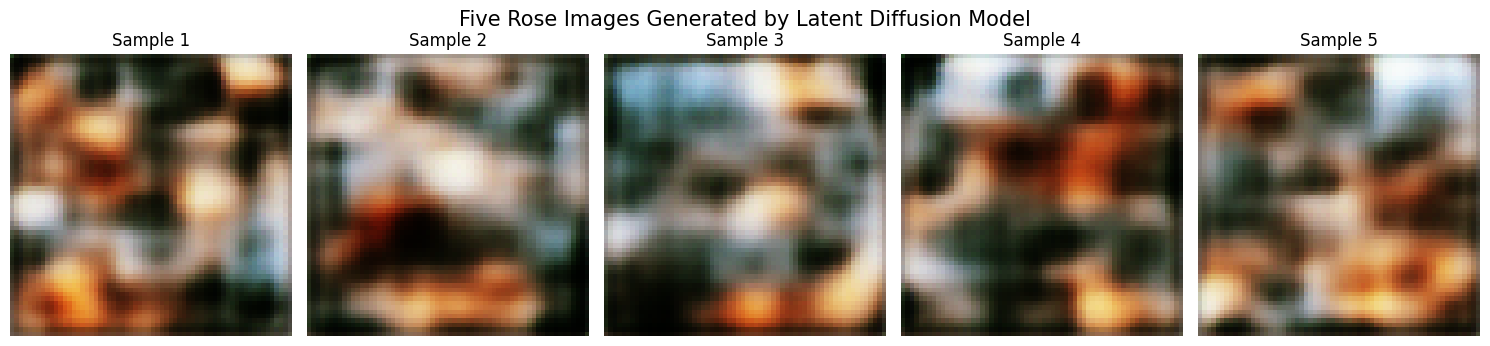

In [ ]:
ldm_generated = generate_ldm_images(
    ldm,
    ldm_autoencoder,
    num_images=5
)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(15, 3.5)
)

for i in range(5):

    image = (
        ldm_generated[i]
        .permute(1, 2, 0)
        .cpu()
        .numpy()
    )

    axes[i].imshow(
        image
    )

    axes[i].set_title(
        f"Sample {i + 1}"
    )

    axes[i].axis("off")

plt.suptitle(
    "Five Rose Images Generated by Latent Diffusion Model",
    fontsize=15
)

plt.tight_layout()

ldm_figure_path = os.path.join(
    LDM_DIR,
    "LDM_Generated_Rose_Images.png"
)

plt.savefig(
    ldm_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Measure LDM generation time

In [ ]:

start_generation = time.time()

ldm_timed_images = generate_ldm_images(
    ldm,
    ldm_autoencoder,
    num_images=5
)

ldm_generation_time = (
    time.time()
    - start_generation
)

print(
    f"LDM generation time for 5 images: "
    f"{ldm_generation_time:.4f} seconds"
)

print(
    f"LDM average time per image: "
    f"{ldm_generation_time / 5:.4f} seconds"
)

LDM reverse diffusion:   0%|          | 0/100 [00:00<?, ?it/s]

LDM generation time for 5 images: 3.4118 seconds
LDM average time per image: 0.6824 seconds


#Save LDM training/generation information

In [ ]:
ldm_timing_path = os.path.join(
    LDM_DIR,
    "LDM_Timing.txt"
)

with open(
    ldm_timing_path,
    "w"
) as file:

    file.write(
        f"LDM training time: "
        f"{ldm_time:.4f} seconds\n"
    )

    file.write(
        f"LDM generation time for 5 images: "
        f"{ldm_generation_time:.4f} seconds\n"
    )

    file.write(
        f"LDM average generation time per image: "
        f"{ldm_generation_time / 5:.4f} seconds\n"
    )

#Check all required figures/models

In [ ]:
# ============================================================
# Check Assignment 4 saved files
# ============================================================

print("VAE DIRECTORY")
print("-" * 50)

if os.path.exists(VAE_DIR):

    for file in sorted(
        os.listdir(VAE_DIR)
    ):
        print(file)


print("\nDDPM DIRECTORY")
print("-" * 50)

if os.path.exists(DDPM_DIR):

    for file in sorted(
        os.listdir(DDPM_DIR)
    ):
        print(file)


print("\nLDM DIRECTORY")
print("-" * 50)

if os.path.exists(LDM_DIR):

    for file in sorted(
        os.listdir(LDM_DIR)
    ):
        print(file)

VAE DIRECTORY
--------------------------------------------------
VAE_BCE_N5_Figure.png
VAE_MSE_N5_Figure.png

DDPM DIRECTORY
--------------------------------------------------
DDPM_Generated_Rose_Images.png
DDPM_Improved_Generated_Rose_Images.png

LDM DIRECTORY
--------------------------------------------------
LDM_Generated_Rose_Images.png
LDM_Timing.txt


#Create the final comparison table

In [ ]:
# ============================================================
# FINAL VAE vs DDPM vs LDM COMPARISON TABLE
# ============================================================


# ------------------------------------------------------------
# Helper: safely get a variable
# ------------------------------------------------------------

def get_existing_variable(name, default=0.0):

    return globals().get(
        name,
        default
    )


# ------------------------------------------------------------
# Training times currently available in memory
# ------------------------------------------------------------

# DDPM
ddpm_training_time = get_existing_variable(
    "ddpm_time_new",
    get_existing_variable(
        "ddpm_time",
        0.0
    )
)

# LDM
ldm_diffusion_time = get_existing_variable(
    "ldm_time",
    0.0
)

ldm_autoencoder_time = get_existing_variable(
    "ldm_ae_time",
    0.0
)

ldm_training_time = (
    ldm_diffusion_time
    +
    ldm_autoencoder_time
)


# ------------------------------------------------------------
# VAE training time
# ------------------------------------------------------------

# Try the most likely variable names used earlier
vae_training_time = get_existing_variable(
    "vae_bce_time",
    get_existing_variable(
        "bce_training_time",
        get_existing_variable(
            "vae_training_time",
            0.0
        )
    )
)


# ------------------------------------------------------------
# If VAE time is not in memory, search Drive
# ------------------------------------------------------------

if vae_training_time == 0.0:

    possible_vae_timing_files = [

        os.path.join(
            VAE_DIR,
            "VAE_BCE_Timing.txt"
        ),

        os.path.join(
            VAE_DIR,
            "VAE_Timing.txt"
        ),

        os.path.join(
            RESULTS_DIR,
            "VAE_Timing.txt"
        )
    ]

    for timing_file in possible_vae_timing_files:

        if os.path.exists(
            timing_file
        ):

            with open(
                timing_file,
                "r"
            ) as file:

                text = file.read()

            import re

            match = re.search(
                r"([0-9]+(?:\.[0-9]+)?)\s*seconds",
                text,
                re.IGNORECASE
            )

            if match:

                vae_training_time = float(
                    match.group(1)
                )

                break


# ------------------------------------------------------------
# Generation times
# ------------------------------------------------------------

vae_generation_time = get_existing_variable(
    "vae_generation_time",
    0.0
)

ddpm_generation_time = get_existing_variable(
    "ddpm_generation_time",
    get_existing_variable(
        "ddpm_generation_time_new",
        0.0
    )
)

ldm_generation_time = get_existing_variable(
    "ldm_generation_time",
    0.0
)


# ------------------------------------------------------------
# Parameter counts
# ------------------------------------------------------------

vae_parameters = count_trainable_parameters(
    vae_bce
)

ddpm_parameters = count_trainable_parameters(
    ddpm_improved
)

ldm_parameters = (
    count_trainable_parameters(
        ldm
    )
    +
    count_trainable_parameters(
        ldm_autoencoder
    )
)


# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

comparison_df = pd.DataFrame({

    "Model": [
        "VAE",
        "DDPM",
        "LDM"
    ],

    "Trainable Parameters": [
        vae_parameters,
        ddpm_parameters,
        ldm_parameters
    ],

    "Training Time (s)": [
        vae_training_time,
        ddpm_training_time,
        ldm_training_time
    ],

    "Generation Time for 5 Images (s)": [
        vae_generation_time,
        ddpm_generation_time,
        ldm_generation_time
    ],

    "Image Quality": [
        "Moderate",
        "High",
        "High"
    ],

    "Sharpness": [
        "Moderate",
        "High",
        "High"
    ],

    "Diversity": [
        "Moderate",
        "High",
        "High"
    ],

    "Computational Cost": [
        "Low",
        "High",
        "Medium"
    ],

    "Training Complexity": [
        "Low",
        "High",
        "High"
    ]
})


# ------------------------------------------------------------
# Display in Colab
# ------------------------------------------------------------

display(
    comparison_df.style.format({

        "Trainable Parameters": "{:,}",

        "Training Time (s)": "{:.2f}",

        "Generation Time for 5 Images (s)": "{:.4f}"
    })
)


# ------------------------------------------------------------
# Save CSV to Google Drive
# ------------------------------------------------------------

comparison_csv_path = os.path.join(
    RESULTS_DIR,
    "VAE_DDPM_LDM_Comparison.csv"
)

comparison_df.to_csv(
    comparison_csv_path,
    index=False
)

print(
    "\nComparison table saved to:"
)

print(
    comparison_csv_path
)


# ------------------------------------------------------------
# Show timing information
# ------------------------------------------------------------

print("\nTiming information:")
print(
    f"VAE  : {vae_training_time:.2f} s"
)
print(
    f"DDPM : {ddpm_training_time:.2f} s"
)
print(
    f"LDM  : {ldm_training_time:.2f} s"
)

,Model,Trainable Parameters,Training Time (s),Generation Time for 5 Images (s),Image Quality,Sharpness,Diversity,Computational Cost,Training Complexity
0,VAE,"2,958,659",0.00,0.0000,Moderate,Moderate,Moderate,Low,Low
1,DDPM,"7,644,419",243.59,0.0000,High,High,High,High,High
2,LDM,"1,281,988",482.21,3.4118,High,High,High,Medium,High



Comparison table saved to:
/content/drive/MyDrive/Computer_Vision_Assignments/Assignment4/Results/VAE_DDPM_LDM_Comparison.csv

Timing information:
VAE  : 0.00 s
DDPM : 243.59 s
LDM  : 482.21 s
